In [2]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style= "whitegrid")

In [3]:
df= pd.read_csv("./Chocolate_Sales.csv")

df.dtypes

Sales Person     object
Country          object
Product          object
Date             object
Amount           object
Boxes Shipped     int64
dtype: object

In [4]:
# 1. Convert Date to datetime format
df["Date"]= pd.to_datetime(df["Date"], dayfirst= True)

# 2. Clean the Amount column and convert to numeric
df["Amount"]= df["Amount"].replace(r"[\$,]", "", regex= True)
df["Amount"]= pd.to_numeric(df["Amount"])

df.dtypes

Sales Person             object
Country                  object
Product                  object
Date             datetime64[ns]
Amount                  float64
Boxes Shipped             int64
dtype: object

In [5]:
df.isna().sum()

Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

In [6]:
df_null= df.copy()
df_null.loc[:5, "Boxes Shipped"]= np.nan

In [7]:
df_null.isna().sum()

Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    6
dtype: int64

In [15]:
# Columns to process
cols_to_fill= ["Amount", "Boxes Shipped"]

for col in cols_to_fill:
    # Condition: If the first element is NaN, fill it with the last element of the column
    if pd.isna(df_null[col].iloc[0]):
        df_null.loc[df_null.index[0], col]= df_null[col].iloc[-1]
    if pd.isna(df_null[col].iloc[-1]):
        df_null.loc[df_null.index[-1], col]= df_null[col].iloc[0]
    # limit= 5 ensures it only fills up to 5 sequential NaNs.
    df_null[col]= df_null[col].interpolate(method= "linear", limit= 5)

# Check remaining missing values
df_null.isna().sum()

Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

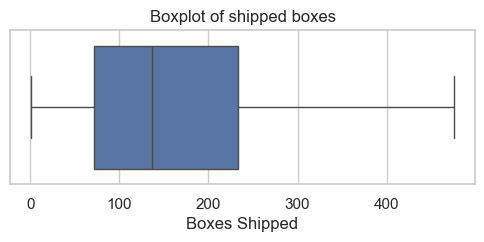

In [16]:
plt.figure(figsize= (6, 2))
sns.boxplot(x= df_null["Boxes Shipped"])
plt.title("Boxplot of shipped boxes")
plt.show()

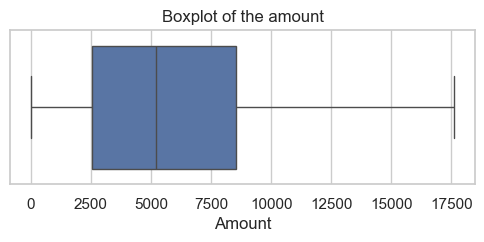

In [17]:
plt.figure(figsize= (6, 2))
sns.boxplot(x= df_null["Amount"])
plt.title("Boxplot of the amount")
plt.show()

In [18]:
def handle_outliers_iqr(dataframe: pd.DataFrame, column: str):
    Q1= dataframe[column].quantile(0.25)
    Q3= dataframe[column].quantile(0.75)
    IQR= Q3 - Q1
    
    lower_bound= Q1 - 1.5 * IQR
    upper_bound= Q3 + 1.5 * IQR
    
    # Clip the outliers to the upper and lower bounds
    dataframe[column]= np.where(dataframe[column] < lower_bound, lower_bound, dataframe[column])
    dataframe[column]= np.where(dataframe[column] > upper_bound, upper_bound, dataframe[column])
    
    return dataframe

# Apply to our numeric features
df_null= handle_outliers_iqr(df_null, "Amount")
df_null= handle_outliers_iqr(df_null, "Boxes Shipped")


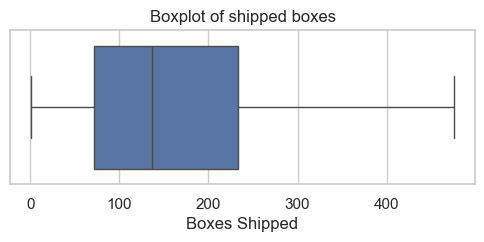

In [19]:
plt.figure(figsize= (6, 2))
sns.boxplot(x= df_null["Boxes Shipped"])
plt.title("Boxplot of shipped boxes")
plt.show()

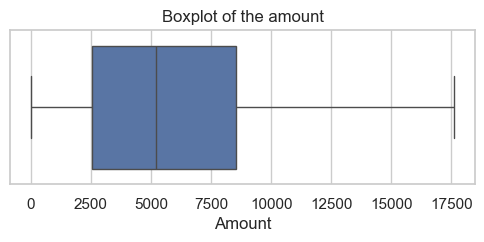

In [20]:
plt.figure(figsize= (6, 2))
sns.boxplot(x= df_null["Amount"])
plt.title("Boxplot of the amount")
plt.show()

In [22]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

features= ["Amount", "Boxes Shipped"]

# 1. Min-Max Normalization
minmax_scaler= MinMaxScaler()
df_minmax= df_null.copy()
df_minmax[features]= minmax_scaler.fit_transform(df_null[features])

# 2. Z-score Normalization (Standardization)
z_scaler= StandardScaler()
df_zscore= df_null.copy()
df_zscore[features]= z_scaler.fit_transform(df_null[features])

df_zscore[features].head()

,Amount,Boxes Shipped
0,-0.157898,1.616409
1,0.442345,1.365015
2,-0.348735,1.113620
3,1.567799,0.862225
4,1.791259,0.610830


Explained Variance Ratio: [0.50598606 0.49401394]


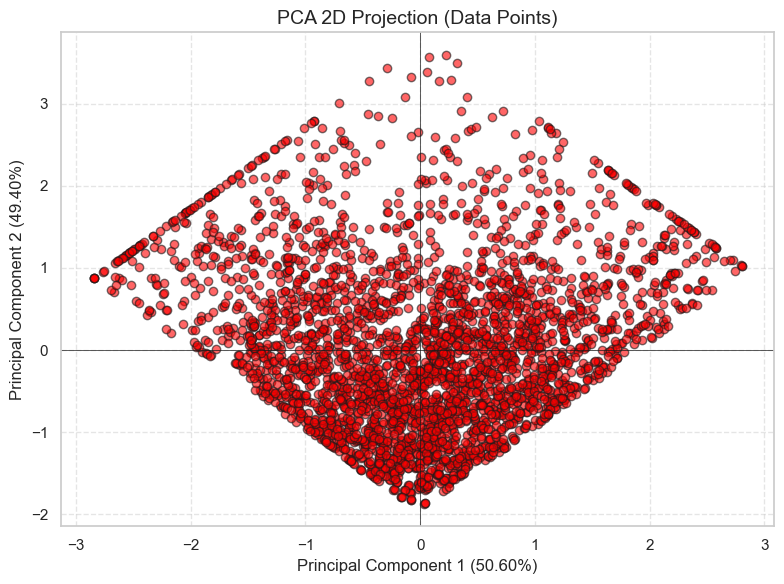

In [29]:
from sklearn.decomposition import PCA

pca= PCA(n_components= 2)
pca_features= pca.fit_transform(df_zscore[features])

# Get Explained Variance Ratio
explained_variance= pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance)

# Normalize the data using z-score (require scaling)
z_scaler= StandardScaler()
scaled_data= z_scaler.fit_transform(df[features])

# Convert the result into a new DataFrame for easy plotting
df_pca= pd.DataFrame(data= pca_features, columns=["PC1", "PC2"])

# Plot the data points
plt.figure(figsize= (8, 6))
plt.scatter(df_pca["PC1"], df_pca["PC2"], alpha= 0.6, color= "red", edgecolors= "k")
plt.title("PCA 2D Projection (Data Points)", fontsize= 14)
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)", fontsize= 12)
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)", fontsize= 12)

# Draw lines through the center (0, 0) in the figure
plt.axhline(y= 0, color= "k", linestyle="-", linewidth= 0.5)
plt.axvline(x= 0, color= "k", linestyle="-", linewidth= 0.5)

plt.grid(True, linestyle= "--", alpha= 0.5)
plt.tight_layout()
plt.show()

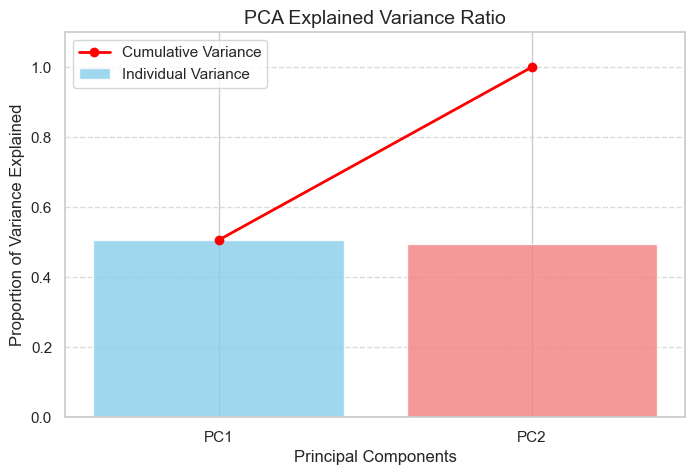

In [32]:
# Explained variance ratio output
components= ["PC1", "PC2"]

fig, ax= plt.subplots(figsize= (8, 5))

# Bar chart for Individual Variance
ax.bar(components, explained_variance, color= ["skyblue", "lightcoral"], alpha= 0.8, label= "Individual Variance")

# Line chart for Cumulative Variance
ax.plot(components, np.cumsum(explained_variance), marker= "o", color= "red", label= "Cumulative Variance", linewidth= 2)

# Formatting the plot
ax.set_title("PCA Explained Variance Ratio", fontsize= 14)
ax.set_xlabel("Principal Components", fontsize= 12)
ax.set_ylabel("Proportion of Variance Explained", fontsize= 12)
ax.set_ylim(0, 1.1) # Variance goes from 0 to 1
ax.legend()
ax.grid(axis= "y", linestyle= "--", alpha= 0.7)

plt.show()

Correlation Matrix:
                  Amount  Boxes Shipped
Amount         1.000000      -0.013154
Boxes Shipped -0.013154       1.000000


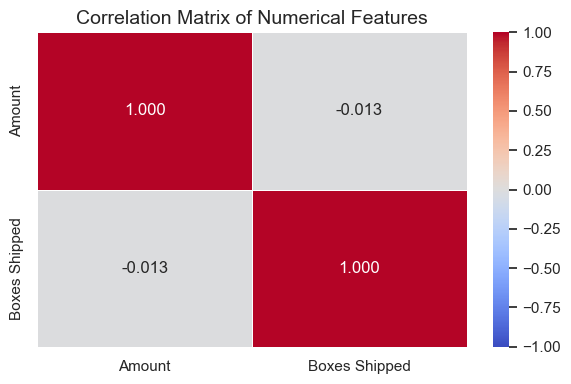

In [33]:
# Calculate the correlation matrix
corr_matrix= df[features].corr()

# Print the exact correlation numbers
print("Correlation Matrix:\n", corr_matrix)

# 3. Draw the correlation heatmap
plt.figure(figsize= (6, 4))
sns.heatmap(corr_matrix, 
            annot= True, # Show the numbers inside the squares
            cmap= "coolwarm",
            vmin= -1, vmax= 1, # Correlation ranges from -1 to 1
            fmt= ".3f", # 3 decimal places
            linewidths= 0.5)
plt.title("Correlation Matrix of Numerical Features", fontsize= 14)
plt.tight_layout()
plt.show()